## **Task 2**

In [1]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=123
)

In [2]:
X.shape

(300, 2)

In [3]:
y.shape

(300,)

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression()
    ),

    "Logistic regression degree 2": make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2),
        LogisticRegression()
    ),

    "Logistic regression degree 3": make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=3),
        LogisticRegression()
    ),

    "Linear SVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),

    "RBF SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf")
    )
}

Logistic regression
Train accuracy: 0.8083333333333333
Test accuracy: 0.8833333333333333


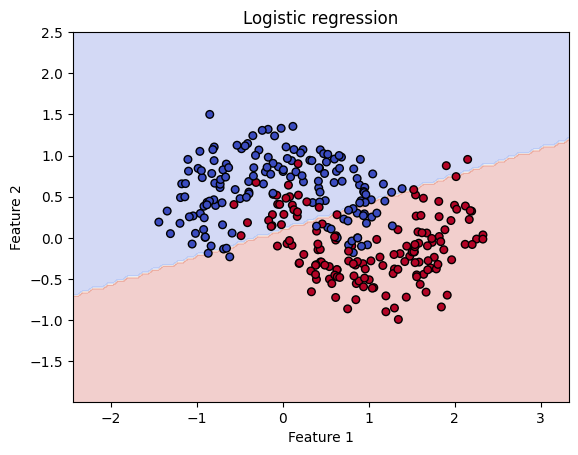

Logistic regression degree 2
Train accuracy: 0.8125
Test accuracy: 0.8833333333333333


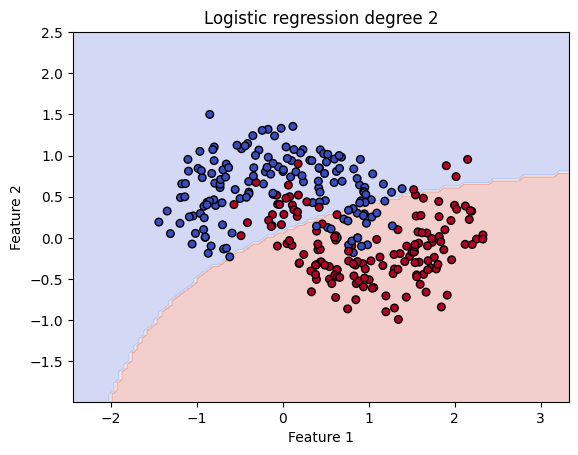

Logistic regression degree 3
Train accuracy: 0.9375
Test accuracy: 0.9166666666666666


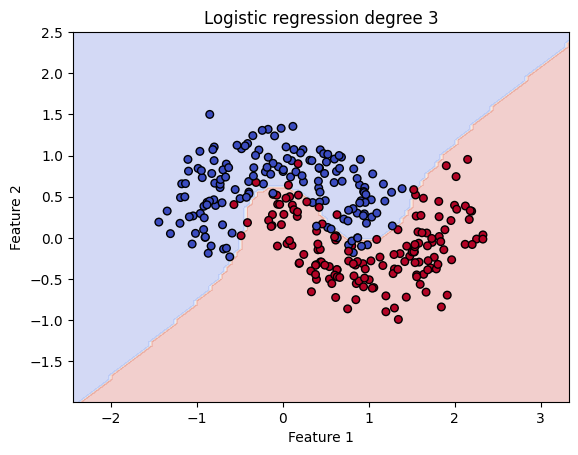

Linear SVM
Train accuracy: 0.8166666666666667
Test accuracy: 0.9


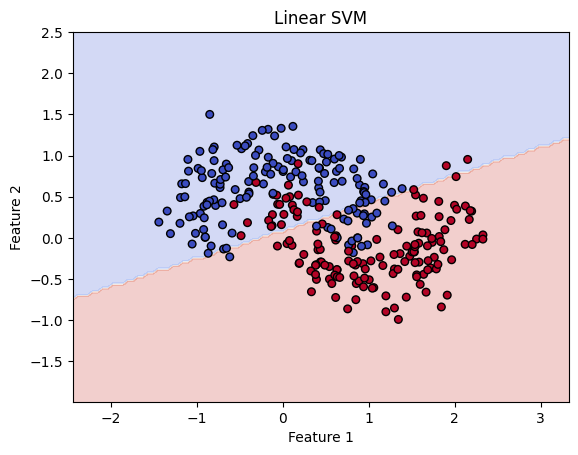

RBF SVM
Train accuracy: 0.9333333333333333
Test accuracy: 0.9333333333333333


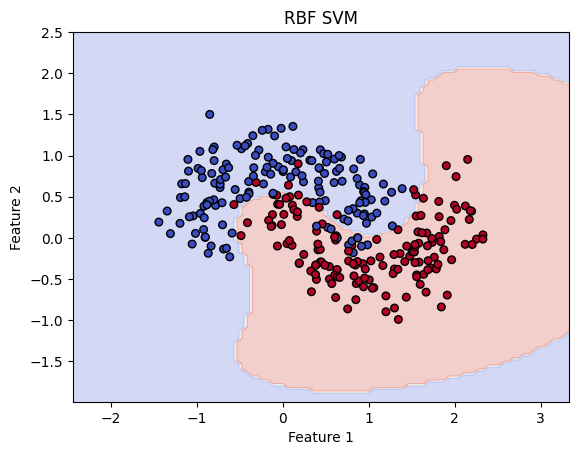

In [25]:
# accuracy & decision regions

for name, model in models.items():
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(name)
    print("Train accuracy:", train_acc)
    print("Test accuracy:", test_acc)

    display = DecisionBoundaryDisplay.from_estimator(
        estimator=model,
        X=X,
        response_method="predict",
        cmap="coolwarm",
        alpha=0.25,
        xlabel="Feature 1",
        ylabel="Feature 2",
    )

    display.ax_.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="k",
        s=30
    )

    plt.title(name)
    plt.show()

    print("================================================================================")

Comparison of shapes of the decision boundaries:
- Logistic Regression: The decision boundary is linear, so it cannot follow the moon shapes.
- Logistic regression with polynomial degree 2: The boundary becomes slightly nonlinear but it is still too simple to properly separate the two moons.
- Logistic regression with polynomial degree 3: The boundary is more flexible and follows the moon shapes better. It gives better accuracy than the two previous logistic regressions.
- Linear SVM: The boundary is also linear, so it has the same limitation as normal logistic regression. It cannot properly model the nonlinear shape of the classes.
- RBF SVM: The boundary is nonlinear and much more suitable (better fitted) to the structure of the data. It adapts best out of all models to the classes in the data and has the biggest accuracy for both train and test sets.

gamma = 0.01
Train accuracy: 0.8125
Test accuracy: 0.8833333333333333



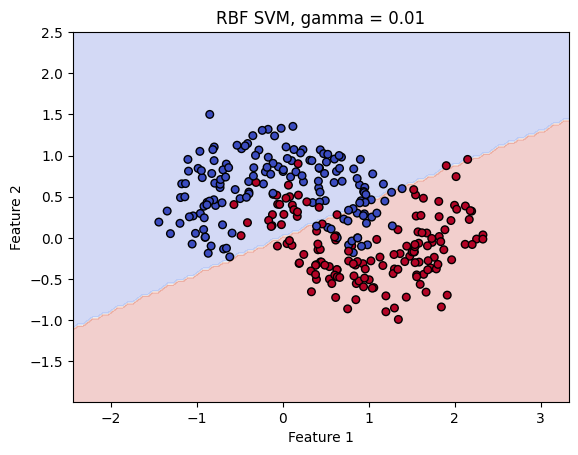

gamma = 0.1
Train accuracy: 0.825
Test accuracy: 0.9



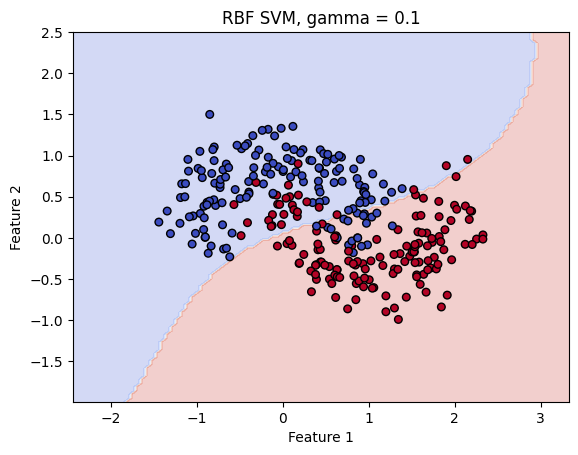

gamma = 1
Train accuracy: 0.9416666666666667
Test accuracy: 0.9



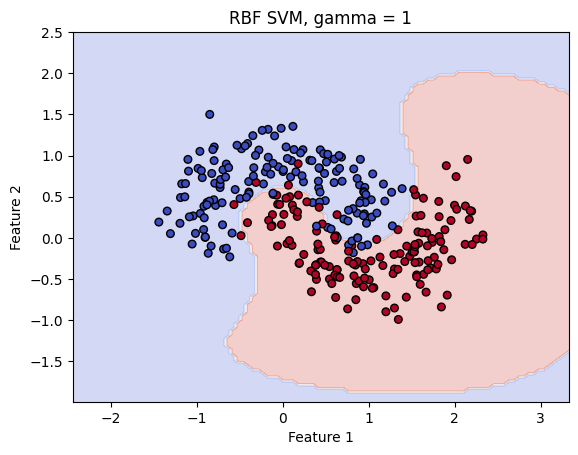

gamma = 10
Train accuracy: 0.9625
Test accuracy: 0.9166666666666666



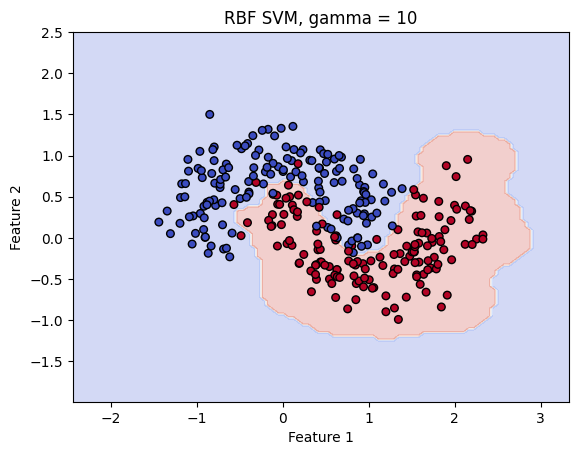

gamma = 100
Train accuracy: 0.9875
Test accuracy: 0.8333333333333334



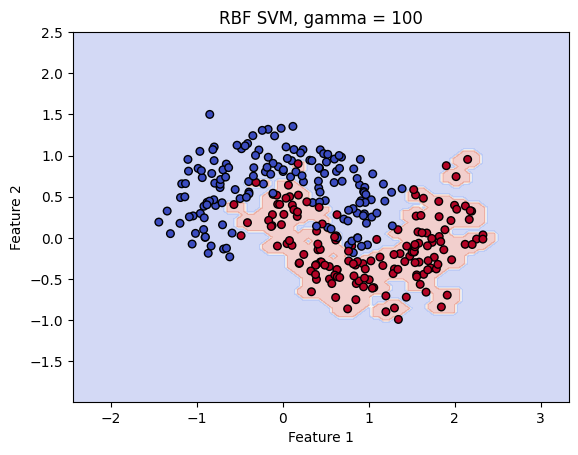

In [ ]:
# rbf svm for different gammas 
# fix C=1
FIXED_C = 1

gamma_values = [0.01, 0.1, 1, 10, 100]

for gamma in gamma_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=FIXED_C, gamma=gamma)
    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"gamma = {gamma}")
    print("Train accuracy:", train_acc)
    print("Test accuracy:", test_acc)
    print()

    display = DecisionBoundaryDisplay.from_estimator(
        estimator=model,
        X=X,
        response_method="predict",
        cmap="coolwarm",
        alpha=0.25,
        xlabel="Feature 1",
        ylabel="Feature 2"
    )

    display.ax_.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="k",
        s=30
    )

    plt.title(f"RBF SVM, gamma = {gamma}")
    plt.show()

    print("================================================================================")

Comparison of the complexity of decision boundaries for different gammas:
- gamma = 0.01: The boundary is very smooth and linear.
- gamma = 0.1: The boundary is quite smooth but starts to be more complex and to adapt to the structure of the data.
- gamma = 1: The boundary's shape is more similar to the shape of data. It's not perfect but it looks good and it's still quite simple.
- gamma = 10: The boundary line is more complex and fits even better to the structure of the data. The test accuracy is the highest here out of all gammas.
- gamma = 100: The boundary line becomes very complex and local. It fits perfectly to the data in the plot. Train accuracy is very high while test accuracy is smaller which suggests overfitting.

### **Questions**

**(a) Why do ordinary logistic regression and linear SVM perform poorly on this dataset?** <br>
Ordinary logistic regression and linear SVM perform poorly on this dataset because they are linear classifiers and the data is not linearly separable - it has a shape of moons.

**(b) Does the logistic regression with polynomial features of degree 3 produce a proper decision boundary for this task?** <br>
It is better than the ordinary logistic regression and the logistic regression with polynomial degree 2 and gives a better nonlinear boundary but it's still not perfect.

**(c) What does the RBF kernel allow the SVM to do?** <br>
RBF kernel allows the SVM to better handle complex data distributions and model a non-linear decision boundary.

**(d) What happens when gamma is very small?** <br>
When gamma is very small the decision boundary is simpler and it might not capture complex structure in data which may lead to underfitting. 

**(e) What happens when gamma is very large?** <br>
Large gamma makes the classifier sensitive to individual points and creates complex decision boundary which may lead to overfitting.

**(f) Compare logistic regression with polynomial features and SVM with RBF kernel. In what sense are these approaches similar, and in what sense are they different?** <br>
They are similar because they both model nonlinear decision boundaries. They are different becasue the logistic regression with polynomial models a boundary according to a fixed polynomial degree while SVM with RBF kernel can create more flexible and complex boundaries. 